In [1]:
# Cell 1 - Imports and load test prediction files

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

model_1_test_path = CLEAN_DIR / "gdp_xgboost_model_1_test_predictions.csv"
model_2_test_path = CLEAN_DIR / "gdp_xgboost_model_2_test_predictions.csv"
model_3_test_path = CLEAN_DIR / "gdp_xgboost_model_3_test_predictions.csv"

print("Model 1 exists:", model_1_test_path.exists())
print("Model 2 exists:", model_2_test_path.exists())
print("Model 3 exists:", model_3_test_path.exists())

model_1_test_df = pd.read_csv(model_1_test_path)
model_2_test_df = pd.read_csv(model_2_test_path)
model_3_test_df = pd.read_csv(model_3_test_path)

print("Model 1 shape:", model_1_test_df.shape)
print("Model 2 shape:", model_2_test_df.shape)
print("Model 3 shape:", model_3_test_df.shape)

Model 1 exists: True
Model 2 exists: True
Model 3 exists: True
Model 1 shape: (1042, 22)
Model 2 shape: (813, 25)
Model 3 shape: (813, 38)


In [2]:
# Cell B - Keep only the common test sample across all 3 models

join_cols = ["country_code", "feature_year", "target_year"]

m1 = model_1_test_df[
    join_cols + ["country_name", "wb_region", "actual_gdp_next_year", "predicted_gdp_next_year"]
].copy().rename(
    columns={"predicted_gdp_next_year": "pred_model_1"}
)

m2 = model_2_test_df[
    join_cols + ["actual_gdp_next_year", "predicted_gdp_next_year"]
].copy().rename(
    columns={"predicted_gdp_next_year": "pred_model_2"}
)

m3 = model_3_test_df[
    join_cols + ["actual_gdp_next_year", "predicted_gdp_next_year"]
].copy().rename(
    columns={"predicted_gdp_next_year": "pred_model_3"}
)

common_test_df = (
    m1.merge(
        m2[join_cols + ["pred_model_2"]],
        on=join_cols,
        how="inner"
    )
    .merge(
        m3[join_cols + ["pred_model_3"]],
        on=join_cols,
        how="inner"
    )
)

print("Common test rows:", common_test_df.shape[0])
print("Countries in common sample:", common_test_df["country_code"].nunique())
print("Target year range:", int(common_test_df["target_year"].min()), "-", int(common_test_df["target_year"].max()))

display(common_test_df.head())

Common test rows: 813
Countries in common sample: 167
Target year range: 2019 - 2023


,country_code,feature_year,target_year,country_name,wb_region,actual_gdp_next_year,pred_model_1,pred_model_2,pred_model_3
0,AFG,2018,2019,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",496.6025,537.0414,557.1232,557.5090
1,AFG,2019,2020,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",510.7871,553.2900,553.2654,561.1194
2,AFG,2020,2021,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",356.4962,556.4369,551.4026,567.1313
3,AFG,2021,2022,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",357.2612,376.6730,402.8383,407.7412
4,AFG,2022,2023,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",413.7579,390.6165,427.2987,426.0230


In [3]:
# Cell C - Build yearly mean actual vs predicted table on common test sample

yearly_compare_df = (
    common_test_df.groupby("target_year", as_index=False)
    .agg(
        n_obs=("actual_gdp_next_year", "size"),
        actual_gdp=("actual_gdp_next_year", "mean"),
        model_1_pred=("pred_model_1", "mean"),
        model_2_pred=("pred_model_2", "mean"),
        model_3_pred=("pred_model_3", "mean"),
    )
    .sort_values("target_year")
    .reset_index(drop=True)
)

display(yearly_compare_df)

,target_year,n_obs,actual_gdp,model_1_pred,model_2_pred,model_3_pred
0,2019,166,"15,698.9605","16,402.3935","16,766.1360","16,375.2727"
1,2020,166,"14,549.3612","16,298.3479","16,552.4605","16,159.8303"
2,2021,162,"17,155.0981","15,142.5453","15,422.7333","15,154.9540"
3,2022,160,"18,048.6179","17,228.2102","17,538.5251","17,298.4945"
4,2023,159,"18,914.0876","18,376.8171","18,263.2532","17,848.6621"


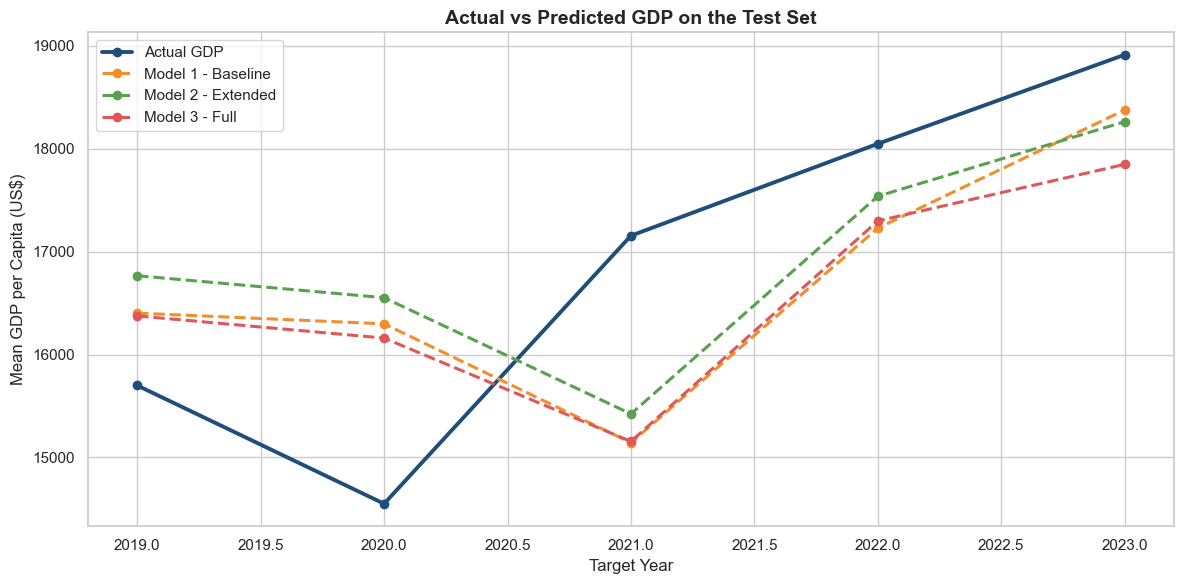

In [5]:
# Cell D - Line chart: Actual vs Predicted on test set

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_compare_df["target_year"],
    yearly_compare_df["actual_gdp"],
    marker="o",
    linewidth=2.8,
    color="#1f4e79",
    label="Actual GDP"
)

plt.plot(
    yearly_compare_df["target_year"],
    yearly_compare_df["model_1_pred"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    color="#f28e2b",
    label="Model 1 - Baseline"
)

plt.plot(
    yearly_compare_df["target_year"],
    yearly_compare_df["model_2_pred"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    color="#59a14f",
    label="Model 2 - Extended"
)

plt.plot(
    yearly_compare_df["target_year"],
    yearly_compare_df["model_3_pred"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    color="#e15759",
    label="Model 3 - Full"
)

plt.title("Actual vs Predicted GDP on the Test Set", fontsize=14, fontweight="bold")
plt.xlabel("Target Year")
plt.ylabel("Mean GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()